Assessment - 1 

1) Import pandas and read in the banklist.csv file into a dataframe called
banks.


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"c:\Users\DELL\Downloads\banklist.csv")
print(df)

                                             Bank Name                City  \
0                                  Fayette County Bank          Saint Elmo   
1    Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee   
2                                       First NBC Bank         New Orleans   
3                                        Proficio Bank  Cottonwood Heights   
4                        Seaway Bank and Trust Company             Chicago   
..                                                 ...                 ...   
548                                 Superior Bank, FSB            Hinsdale   
549                                Malta National Bank               Malta   
550                    First Alliance Bank & Trust Co.          Manchester   
551                  National State Bank of Metropolis          Metropolis   
552                                   Bank of Honolulu            Honolulu   

     ST   CERT                Acquiring Institution Closing Dat

2) Show the head of the dataframe.


In [3]:
df.head()

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,26-Jul-17
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,5-May-17,26-Jul-17
2,First NBC Bank,New Orleans,LA,58302,Whitney Bank,28-Apr-17,26-Jul-17
3,Proficio Bank,Cottonwood Heights,UT,35495,Cache Valley Bank,3-Mar-17,18-May-17
4,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,27-Jan-17,18-May-17


3) What are the column names?

In [4]:
df.columns

Index(['Bank Name', 'City', 'ST', 'CERT', 'Acquiring Institution',
       'Closing Date', 'Updated Date'],
      dtype='object')

4) How many States (ST) are represented in this data set?

In [6]:
df['ST'].nunique()

44

5) Get a list or array of all the states in the data set.


In [7]:
df['ST'].unique()

array(['IL', 'WI', 'LA', 'UT', 'NJ', 'AR', 'GA', 'PA', 'TN', 'WA', 'CO',
       'PR', 'FL', 'MN', 'CA', 'MD', 'OK', 'OH', 'SC', 'VA', 'ID', 'TX',
       'CT', 'AZ', 'NV', 'NC', 'KY', 'MO', 'KS', 'AL', 'MI', 'IN', 'IA',
       'NE', 'MS', 'NM', 'OR', 'NY', 'MA', 'SD', 'WY', 'WV', 'NH', 'HI'],
      dtype=object)

6) What are the top 5 states with the most failed banks?

In [8]:
df['ST'].value_counts().head(5)

ST
GA    93
FL    75
IL    68
CA    41
MN    23
Name: count, dtype: int64

7) What are the top 5 acquiring institutions?

In [9]:
df['Acquiring Institution'].value_counts().head(5)

Acquiring Institution
No Acquirer                            31
State Bank and Trust Company           12
First-Citizens Bank & Trust Company    11
Ameris Bank                            10
U.S. Bank N.A.                          9
Name: count, dtype: int64

8) How many banks has the State Bank of Texas acquired? How many of
them were actually in Texas?

In [13]:
print(((df['Acquiring Institution'] == 'State Bank of Texas').sum(), ((df['Acquiring Institution'] == 'State Bank of Texas') & (df['ST'] == 'TX')).sum()))

(np.int64(3), np.int64(1))


9) What is the most common city in California for a bank to fail in?

In [14]:
print(df[df['ST'] == 'CA']['City'].value_counts().idxmax())

Los Angeles


Assessment 2

In [15]:
import pandas as pd

In [16]:
df = pd.read_csv(r"c:\Users\DELL\Downloads\historical_automobile_sales.csv")
print(df)

           Date  Year Month  Recession  Consumer_Confidence  \
0     1/31/1980  1980   Jan          1               108.24   
1     2/29/1980  1980   Feb          1                98.75   
2     3/31/1980  1980   Mar          1               107.48   
3     4/30/1980  1980   Apr          1               115.01   
4     5/31/1980  1980   May          1                98.72   
..          ...   ...   ...        ...                  ...   
523   8/31/2023  2023   Aug          0               103.36   
524   9/30/2023  2023   Sep          0               101.55   
525  10/31/2023  2023   Oct          0               124.66   
526  11/30/2023  2023   Nov          0                97.09   
527  12/31/2023  2023   Dec          0                95.92   

     Seasonality_Weight      Price  Advertising_Expenditure  Competition  \
0                  0.50  27483.571                     1558            7   
1                  0.75  24308.678                     3048            4   
2              

Q 1: Develop a Line chart using the functionality of pandas to show how
automobile sales fluctuate from year to year. 

In [17]:
import matplotlib.pyplot as plt

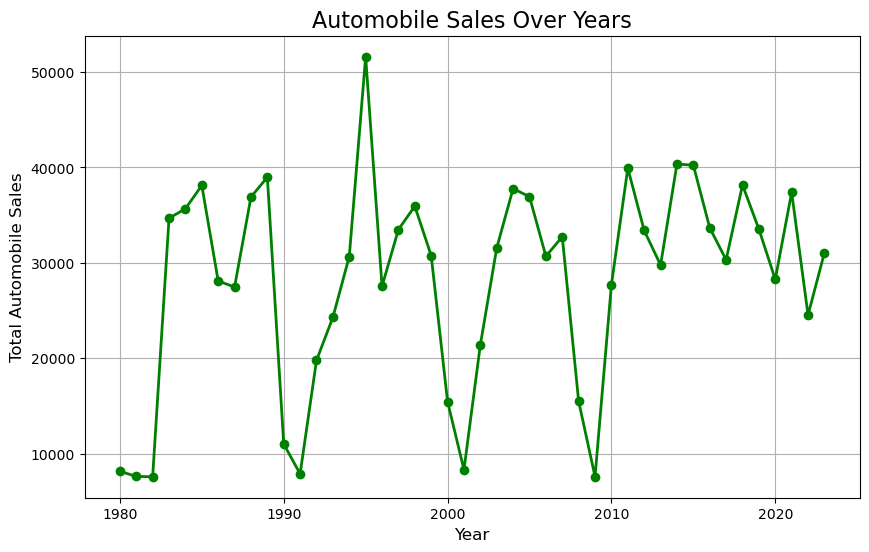

In [19]:
# Group by Year and sum the automobile sales
yearly_sales = df.groupby('Year')['Automobile_Sales'].sum()

# Plotting
plt.figure(figsize=(10,6))
yearly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title("Automobile Sales Over Years", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Automobile Sales", fontsize=12)
plt.grid(True)
plt.show()

Q 2: Plot different lines for categories of vehicle type and analyze the trend
to answer the question Is there a noticeable difference in sales trends
between different vehicle types during recession periods? 

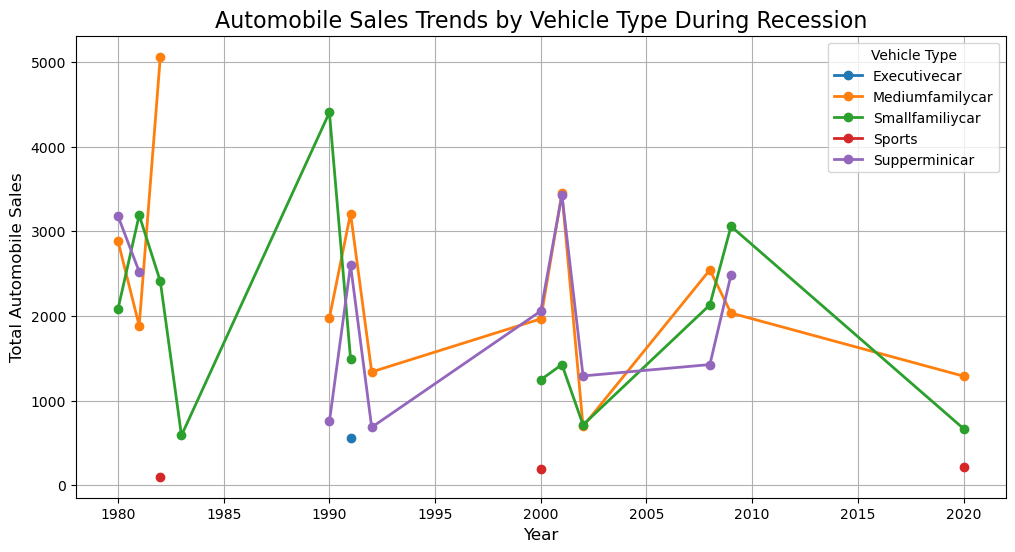

In [20]:
recession_df = df[df['Recession'] == 1]
vehicle_sales = recession_df.groupby(['Year', 'Vehicle_Type'])['Automobile_Sales'].sum().unstack()
plt.figure(figsize=(12,6))
for vehicle_type in vehicle_sales.columns:
    plt.plot(vehicle_sales.index, vehicle_sales[vehicle_type], marker='o', linewidth=2, label=vehicle_type)

plt.title("Automobile Sales Trends by Vehicle Type During Recession", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Automobile Sales", fontsize=12)
plt.legend(title="Vehicle Type")
plt.grid(True)
plt.show()

Q 3: Use the functionality of Seaborn Library to create a visualization to compare
the sales trend per vehicle type for a recession period with a non- recession
period. 


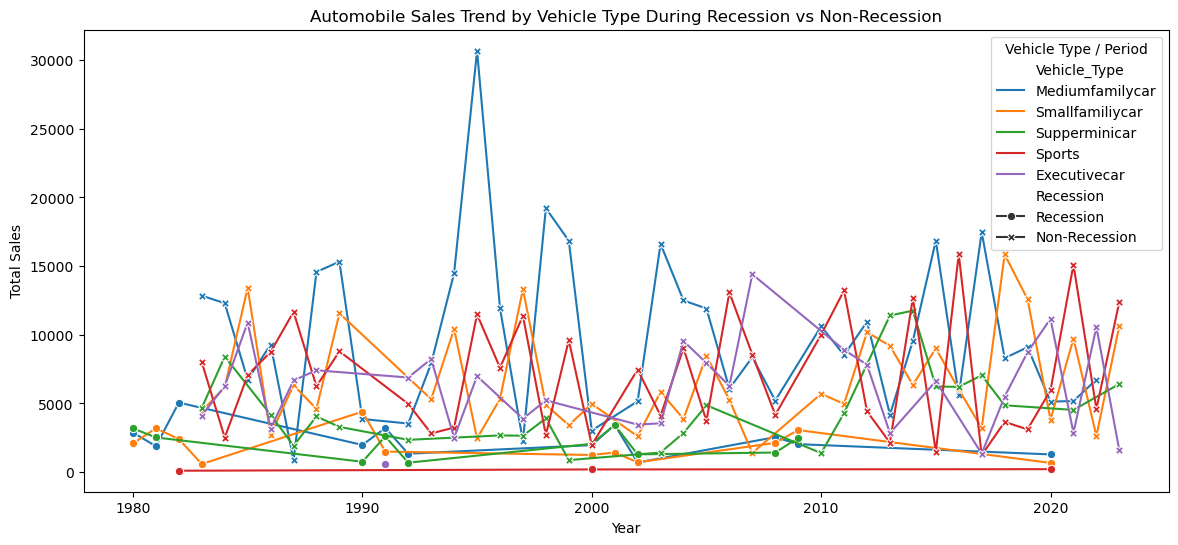

In [22]:
# Convert 'Date' column to datetime if needed
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate sales by Year, Vehicle_Type, and Recession
sales_trend = df.groupby(['Year', 'Vehicle_Type', 'Recession'])['Automobile_Sales'].sum().reset_index()

# Map Recession for readability
sales_trend['Recession'] = sales_trend['Recession'].map({1: 'Recession', 0: 'Non-Recession'})

# Plot using Seaborn
plt.figure(figsize=(14,6))
sns.lineplot(
    data=sales_trend, 
    x='Year', 
    y='Automobile_Sales', 
    hue='Vehicle_Type', 
    style='Recession', 
    markers=True, 
    dashes=False
)
plt.title('Automobile Sales Trend by Vehicle Type During Recession vs Non-Recession')
plt.ylabel('Total Sales')
plt.xlabel('Year')
plt.legend(title='Vehicle Type / Period')
plt.show()

Q 4: Now you want to compare the sales of different vehicle types
during a recession and a non-recession period 

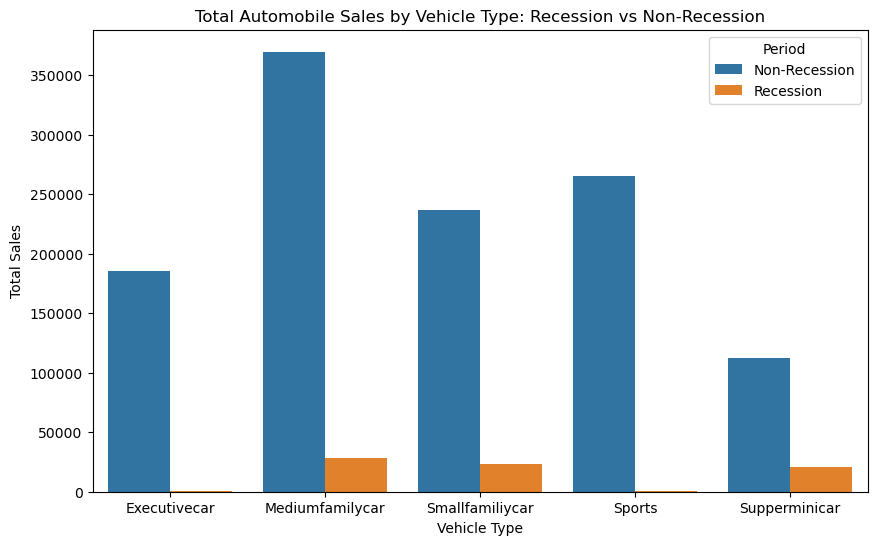

In [23]:
# Map Recession values for readability
df['Recession'] = df['Recession'].map({1: 'Recession', 0: 'Non-Recession'})

# Aggregate total sales per Vehicle_Type and Recession
vehicle_sales = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].sum().reset_index()

# Plot using Seaborn
plt.figure(figsize=(10,6))
sns.barplot(
    data=vehicle_sales,
    x='Vehicle_Type',
    y='Automobile_Sales',
    hue='Recession'
)
plt.title('Total Automobile Sales by Vehicle Type: Recession vs Non-Recession')
plt.ylabel('Total Sales')
plt.xlabel('Vehicle Type')
plt.legend(title='Period')
plt.show()